In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import warnings

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [ ]:
pd.options.mode.chained_assignment = None

all_cases_best_results = {}
cases = ['solu_nophys', 'solu_1e-2phys', 'solu_1phys','solu_1e1phys','solu_1e3phys','solu_1e6phys', 'solu_nodata']  # Case identifiers corresponding to different lambda values

for case_id in cases:
    all_runs_best_results_list = []
    print(f"Processing case: {case_id}...")
    
    for run_num in range(10):
        try:
            history_df = pd.read_csv(f"../sweep_results/metrics_log/loss_history_df_{case_id}_{run_num}.csv")
            
            best_results = []
            for size in [5,10,20,40,60]:
                size_df = history_df[history_df['data_size'] == size].copy()
        
                best_epoch_row = size_df.loc[size_df['val_loss'].idxmin()]

                best_results.append({
                    'data_size': size,
                    'best_val_loss': best_epoch_row['val_loss'],
                    'test_loss_at_best': best_epoch_row['test_loss'],
                    'best_epoch': best_epoch_row['epoch']
                })
        except:
            continue
        all_runs_best_results_list.append(pd.DataFrame(best_results))
        

    all_runs_df = pd.concat(all_runs_best_results_list)
    
    mean_results = all_runs_df.groupby('data_size').mean()
    sem_results = all_runs_df.groupby('data_size').sem()
    
    all_cases_best_results[case_id] = {'mean': mean_results, 'sem': sem_results}

Processing case: solu_nophys...
Processing case: solu_1e-2phys...
Processing case: solu_1phys...
Processing case: solu_1e1phys...
Processing case: solu_1e3phys...
Processing case: solu_1e6phys...
Processing case: solu_nodata...


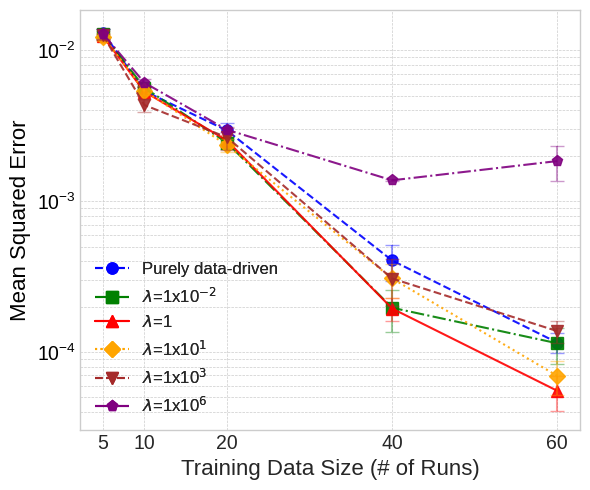

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(6,5), tight_layout = True)

colors = {'solu_nophys': 'blue', 'solu_1e-2phys': 'green', 
          'solu_1phys': 'red', 'solu_1e1phys': 'orange', 
          'solu_1e3phys': 'brown', 'solu_1e6phys':'purple'}
case_labels = {'solu_nophys': 'Purely data-driven', 'solu_1e-2phys': r'$\lambda$=1x10$^{-2}$',
               'solu_1phys': r'$\lambda$=1', 'solu_1e1phys': r'$\lambda$=1x10$^{1}$', 
               'solu_1e3phys': r'$\lambda$=1x10$^{3}$', 'solu_1e6phys': r'$\lambda$=1x10$^{6}$'}

linestyles = {'solu_nophys': '--', 'solu_1e-2phys': '-.', 
              'solu_1phys': '-', 'solu_1e1phys': ':', 
              'solu_1e3phys': '--', 'solu_1e6phys': '-.'}

markers = {'solu_nophys': 'o', 'solu_1e-2phys': 's', 
           'solu_1phys': '^', 'solu_1e1phys': 'D', 
           'solu_1e3phys': 'v', 'solu_1e6phys': 'p'}

ordered_cases = ['solu_nophys', 'solu_1e-2phys', 'solu_1phys', 
                 'solu_1e1phys', 'solu_1e3phys', 'solu_1e6phys']

for case_id, results_data in all_cases_best_results.items():
    if case_id not in ordered_cases:
        continue
    mean_df = results_data['mean']
    sem_df = results_data['sem']
    color = colors.get(case_id, 'black')
    l_style = linestyles.get(case_id, '-')
    m_style = markers.get(case_id, 'o')
    x_values = mean_df.index 

    metric_mean = mean_df['test_loss_at_best']
    metric_sem = sem_df['test_loss_at_best']

    ax1.plot(x_values, metric_mean, color=color, linestyle=l_style, marker=m_style, markersize=8, alpha = 0.9, label='Test Error')

    ax1.errorbar(x_values, metric_mean, yerr=metric_sem,
                 color=color, linestyle='none', marker='', 
                 capsize=5, alpha=0.4, elinewidth=1.5)

ax1.set_xlabel('Training Data Size (# of Runs)', fontsize=16)
ax1.set_ylabel('Mean Squared Error', fontsize=16, color='black')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks([5, 10, 20, 40, 60])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

case_patches = [mlines.Line2D([], [], 
                              color=colors[case], 
                              linestyle=linestyles[case], 
                              marker=markers[case], 
                              markersize=8, 
                              label=case_labels[case]) 
                for case in ordered_cases if case in all_cases_best_results]

legend1 = plt.legend(handles=case_patches, ncol=1, fontsize=12, title_fontsize = 14)
plt.gca().add_artist(legend1)
plt.tight_layout()

# plt.savefig("./model_performance_10solu_avg.svg", bbox_inches = 'tight')
# plt.savefig("./model_performance_10solu_avg.png", bbox_inches = 'tight')
# plt.savefig("./model_performance_10solu_avg.pdf", bbox_inches = 'tight')

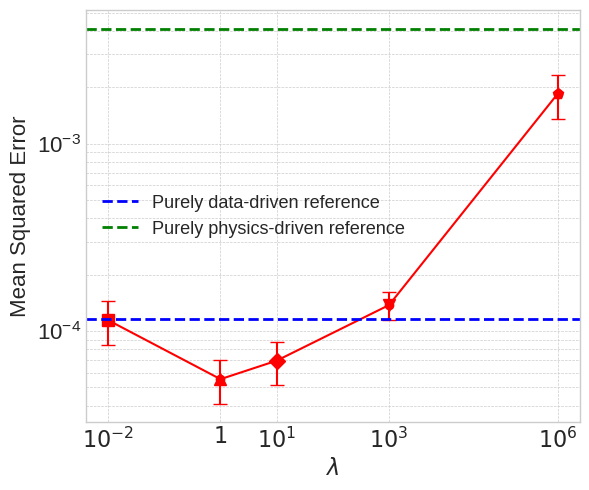

In [ ]:
target_size = 60
lambda_map = {
    'solu_1e-2phys': 1e-2,
    'solu_1phys': 1,
    'solu_1e1phys': 1e1,
    'solu_1e3phys': 1e3,
    'solu_1e6phys': 1e6
}

markers = {
    'solu_nophys': 'o', 
    'solu_1e-2phys': 's', 
    'solu_1phys': '^', 
    'solu_1e1phys': 'D', 
    'solu_1e3phys': 'v', 
    'solu_1e6phys': 'p'
}

lambda_results = []
for case_id, val in lambda_map.items():
    if case_id in all_cases_best_results:
        mean_df = all_cases_best_results[case_id]['mean']
        sem_df = all_cases_best_results[case_id]['sem']
        
        if target_size in mean_df.index:
            lambda_results.append({
                'case_id': case_id,
                'lambda': val,
                'mean_error': mean_df.loc[target_size, 'test_loss_at_best'],
                'sem_error': sem_df.loc[target_size, 'test_loss_at_best']
            })

df_plot = pd.DataFrame(lambda_results).sort_values('lambda')

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(6, 5), tight_layout=True)

ax.plot(df_plot['lambda'], df_plot['mean_error'], 
        linestyle='-', marker='o', color='red')

ax.errorbar(df_plot['lambda'], df_plot['mean_error'], yerr=df_plot['sem_error'],
            color='red', linestyle='none', capsize=5, elinewidth=1.5)

for _, row in df_plot.iterrows():
    case = row['case_id']
    ax.plot(row['lambda'], row['mean_error'], 
            marker=markers[case], color='red', markersize=8, linestyle='none')

# Add horizontal reference lines for purely data-driven and purely physics-driven references
if 'solu_nophys' in all_cases_best_results:
    nophys_mean = all_cases_best_results['solu_nophys']['mean'].loc[target_size, 'test_loss_at_best']
    ax.axhline(y=nophys_mean, color='blue', linestyle='--', label='Purely data-driven reference', linewidth = 2)

if 'solu_nodata' in all_cases_best_results:
    nodata_mean = all_cases_best_results['solu_nodata']['mean'].loc[target_size, 'test_loss_at_best']
    ax.axhline(y=nodata_mean, color='green', linestyle='--', label='Purely physics-driven reference', linewidth = 2)    

ax.set_xscale('log') 
ax.set_yscale('log')

custom_ticks = sorted(lambda_map.values())
ax.set_xticks(custom_ticks)

ax.set_xticklabels(['$10^{-2}$', '$1$', '$10^{1}$', '$10^{3}$','$10^{6}$'])
ax.set_xlabel(r'$\lambda$', fontsize=16)
ax.set_ylabel('Mean Squared Error', fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(fontsize=13)

# plt.savefig("./model_lambda_10solu_60.svg", bbox_inches = 'tight')
# plt.savefig("./model_lambda_10solu_60.png", bbox_inches = 'tight')
# plt.savefig("./model_lambda_10solu_60.pdf", bbox_inches = 'tight')


## Test data

In [ ]:
class PIRNN(nn.Module):
    def __init__(self, n_state=5, n_ctrl=1, hidden=64, layers=2, delta=1, dropout=0.2):
        super().__init__()
        self.n_state = n_state
        self.n_ctrl  = n_ctrl
        self.delta = delta
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=n_state+n_ctrl,
                            hidden_size=hidden,
                            num_layers=layers,
                            batch_first=True,
                            dropout=dropout if layers > 1 else 0)
        self.batch_norm = nn.BatchNorm1d(hidden)
        self.fc = nn.Linear(hidden, n_state)

        self.noise_scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, x0, T_seq):
        batch, N, _ = T_seq.shape
        x0 = x0.unsqueeze(1).expand(-1, N, -1)
        lstm_in = torch.cat([x0, T_seq], dim=-1)
        out, _ = self.lstm(lstm_in)
        
        out_reshaped = out.reshape(-1, out.shape[-1])
        out_norm = self.batch_norm(out_reshaped)
        out_norm = out_norm.reshape(out.shape)
        out_norm = self.dropout(out_norm)
        
        x_hat = self.fc(out)
        return torch.nn.functional.softplus(x_hat)

model = PIRNN().to(device)

In [ ]:
kv = 0.797  # -
rho = 1.263  # [rho] = g/cm^3
R = 8.314  # J/mol.K

def odefun_pred(t, x, T_func, params):
    mu0, mu1, mu2, mu3, conc = x
    kb2, alfa, beta, kg, Eag, gama_g = np.exp(params)

    ms = kv * rho * mu3 * 1e3

    T = T_func(t)

    T_K = T + 273.15 
    Ceq = (
        -16.17
        + 1.765e-1 * T_K
        - 6.439e-4 * T_K ** 2
        + 7.915e-7 * T_K ** 3
    )  # g/g

    S = conc / Ceq

    B2 = kb2 * (max(S - 1, 0) ** alfa) * (ms ** beta)

    G = kg * np.exp(-Eag / (R * T_K)) * max(conc - Ceq, 0) ** gama_g

    dmi0dt = B2
    dmi1dt = G * mu0
    dmi2dt = 2 * G * mu1
    dmi3dt = 3 * G * mu2
    dcdt = -3 * rho * kv * G * mu2

    return [dmi0dt, dmi1dt, dmi2dt, dmi3dt, dcdt]

In [ ]:
test_data = np.load(f"../sweep_results/saved_data/test_data_solushift.npz")
initial_conditions_test = test_data['x0_test']
T_input_test = test_data['T_data_test']
y_data_test = test_data['y_data_test']

In [ ]:
cases = ['solushift_nophys', 'solushift_1e-2phys', 'solushift_1phys','solushift_1e1phys','solushift_1e3phys']
y_scale = np.array([2.95566285e+05, 2.04389833e+03, 2.31127278e+01, 3.52281060e-01,
       4.97344188e-01])   # Obtained from data generation
num_runs = ['5','10','20','40','60']

time_eval = np.arange(501).flatten()
time_span = (time_eval[0], time_eval[-1])
y0 = initial_conditions_test[0]* y_scale
T_profile = T_input_test[0].flatten()
T_func = interp1d(time_eval, T_profile, kind='linear', fill_value="extrapolate")

rhs_param_names = ['kb2', 'alfa', 'beta', 'kg', 'Eag', 'gama_g']

all_case_pred_results = {}
for case in cases:
    
    all_runs_test_pred_list = []
    all_runs_odes_pred_list = []
    for run_num in range(10):
        try:
            state_dict = torch.load(f'../sweep_results/saved_models/best_val_{case}_{run_num}.pth')
        except FileNotFoundError:
            continue

        all_size_test_pred_list = []
        all_size_odes_pred_list = []
        for train_size in num_runs:
            
            # PIRNN forward prediction
            model.load_state_dict(state_dict[train_size]['model_state'])
            params = np.array([state_dict[train_size]['rhs_state'][param_name].item() for param_name in rhs_param_names])
            model.eval()
            with torch.no_grad():
                pred_test = model(torch.tensor(initial_conditions_test, dtype=torch.float32).to(device), torch.tensor(T_input_test, dtype=torch.float32).to(device))

            pred_test = pred_test.detach().cpu().numpy()

            # Reevaluate ODE with PIRNN predicted parameters
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                warnings.simplefilter("ignore", UserWarning)
                sol = solve_ivp(
                    fun=odefun_pred,
                    t_span=time_span,
                    y0=y0,
                    t_eval=time_eval,
                    args=(T_func, params),
                    method='LSODA'
                )
                pred_ode = (sol.y.T / y_scale).T
                
            all_size_test_pred_list.append(pred_test[0,:,3])
            all_size_odes_pred_list.append(pred_ode[3,:].T)
        all_runs_test_pred_list.append(all_size_test_pred_list)
        all_runs_odes_pred_list.append(all_size_odes_pred_list)
                
    mean_test_pred = np.mean(all_runs_test_pred_list, axis = 0)
    mean_odes_pred = np.mean(all_runs_odes_pred_list, axis = 0)
    
    sem_test_pred = np.std(all_runs_test_pred_list, axis = 0, ddof=1)/np.sqrt(len(all_runs_test_pred_list))
    sem_odes_pred = np.std(all_runs_odes_pred_list, axis = 0, ddof=1)/np.sqrt(len(all_runs_odes_pred_list))
    
    all_case_pred_results[case] = {'mean_test_pred':mean_test_pred, 'sem_test_pred':sem_test_pred,
                                      'mean_odes_pred':mean_odes_pred, 'sem_odes_pred':sem_odes_pred}

# Evaluate ODE with ground truth parameters
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    warnings.simplefilter("ignore", UserWarning)
    sol = solve_ivp(
            fun=odefun_pred,
            t_span=time_span,
            y0=y0,
            t_eval=time_eval,
            args=(T_func, np.log(np.array([6e3,2.08,0.713,2.73e5,4.13e4,1.24]))),
            method='LSODA')
pred_gt_param = (sol.y.T / y_scale).T

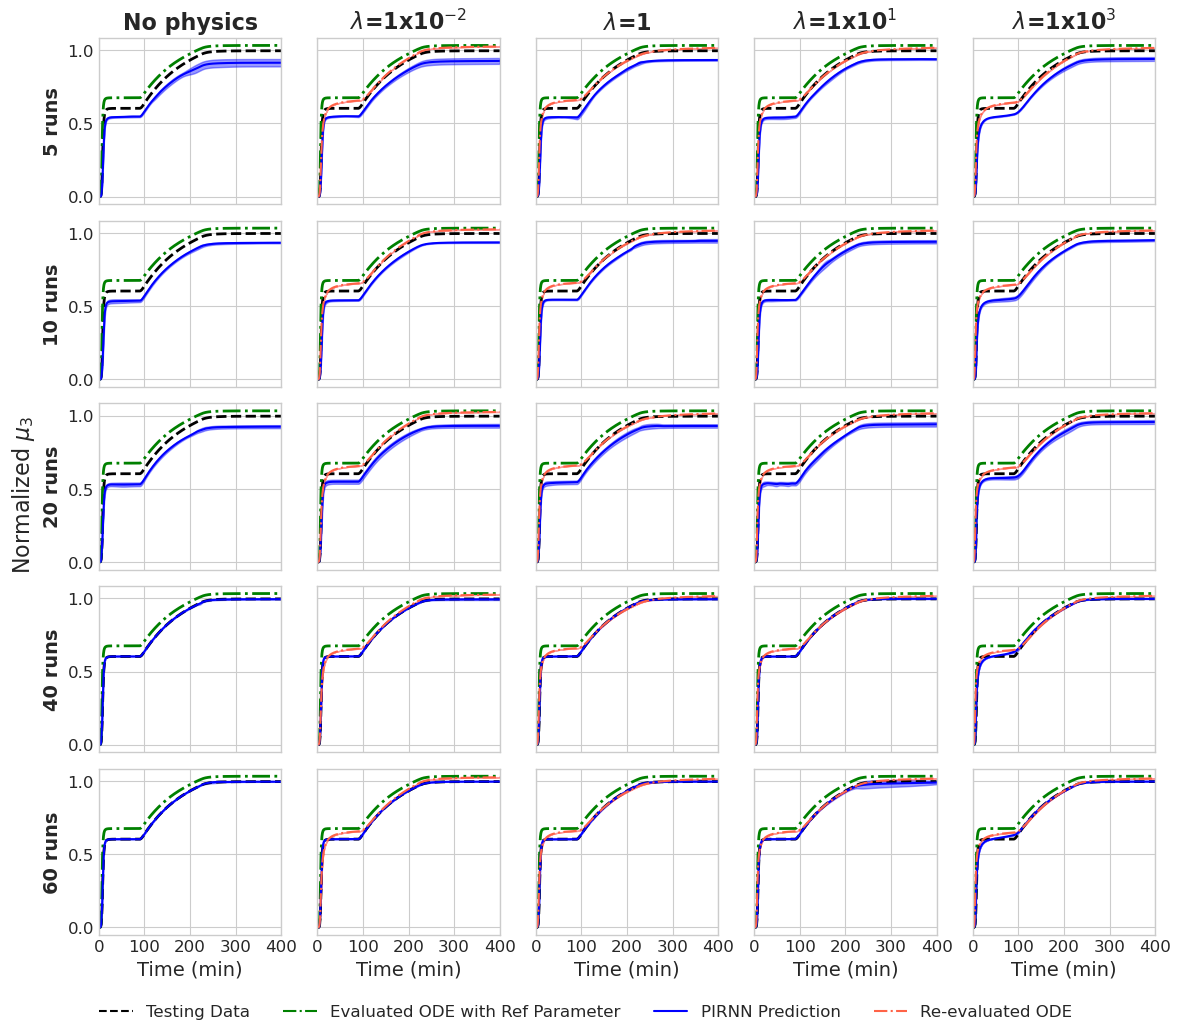

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    5, 5, 
    figsize=(12, 10),
    sharex=True, 
    sharey=True,
    tight_layout = True
)

fig.supylabel(r'Normalized $\mu_3$', fontsize=16, x=0.02)

case_labels = {'solushift_nophys': 'No physics', 'solushift_1e-2phys': r'$\lambda$=1x10$^{-2}$', 
               'solushift_1phys': r'$\lambda$=1', 'solushift_1e1phys': r'$\lambda$=1x10$^{1}$',
               'solushift_1e3phys': r'$\lambda$=1x10$^{3}$'}

cases_to_plot = ['solushift_nophys', 'solushift_1e-2phys', 'solushift_1phys','solushift_1e1phys','solushift_1e3phys']

noiseless_gt = y_data_test[0,:401,3]  # First 401 points for the 3rd state variable (mu3), change index if you want to plot a different variable
time_steps = np.arange(len(noiseless_gt))

for j in range(len(num_runs)):
    axs = axes[j,:]

    for i, case_id in enumerate(cases_to_plot):
        ax = axs[i]
        
        results_data = all_case_pred_results[case_id]

        ax.plot(time_steps, noiseless_gt, color='black', linestyle='--', label='Noiseless Reference', linewidth = 2)

        ax.plot(time_steps, pred_gt_param[3,:401], color='green', linestyle='-.', label='Evaluated ODE with Ref Parameter', linewidth = 2)

        # PIRNN forward prediction with confidence interval
        mean_pred = results_data['mean_test_pred'][j,:][:401]
        sem_pred = results_data['sem_test_pred'][j,:][:401]
        ax.plot(time_steps, mean_pred, color='blue', linestyle='-', label='PIRNNs Prediction', linewidth = 1.5)
        lower_bound = mean_pred - 1.96 * sem_pred
        upper_bound = mean_pred + 1.96 * sem_pred
        ax.fill_between(time_steps, lower_bound, upper_bound, color='blue', alpha=0.4)
        
        # Re-evaluated ODE with confidence interval (only for cases with physics regularization)
        if case_id != 'solushift_nophys':
            mean_odes = results_data['mean_odes_pred'][j,:][:401]
            sem_odes = results_data['sem_odes_pred'][j,:][:401]
            ax.plot(time_steps, mean_odes, color='tomato', linestyle='-.', label='Re-evaluated ODE', linewidth = 1.5)
            lower_bound = mean_odes - 1.96 * sem_odes
            upper_bound = mean_odes + 1.96 * sem_odes
            ax.fill_between(time_steps, lower_bound, upper_bound, color='red', alpha=0.4)

        if j == 0:
            ax.set_title(case_labels.get(case_id), fontsize=16, fontweight='bold')
        if j == 4:
            ax.tick_params(axis='x', which='major', labelsize=12)
            ax.set_xlabel('Time (min)', fontsize=14)
    axs[0].tick_params(axis='y', which='major', labelsize=12)

    row_label = num_runs[j]
    axs[0].set_ylabel(row_label + ' runs', fontsize=14, fontweight='bold')

plt.setp(axes, xlim=(0, 400))

legend_handles = [
    mlines.Line2D([], [], color='black', linestyle='--', label='Testing Data'),
    mlines.Line2D([], [], color='green', linestyle='-.', label='Evaluated ODE with Ref Parameter'),
    mlines.Line2D([], [], color='blue', linestyle='-', label='PIRNN Prediction'),
    mlines.Line2D([], [], color='tomato', linestyle='-.', label='Re-evaluated ODE')
]

fig.legend(handles=legend_handles, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.04), 
           ncol=4, 
           fontsize=12)

# plt.savefig("./test_solushift_mu3.svg", bbox_inches = 'tight')
# plt.savefig("./test_solushift_mu3.png", bbox_inches = 'tight')
# plt.savefig("./test_solushift_mu3.pdf", bbox_inches = 'tight')